 Train Logistic Regression


## IMPORT REQUIRED LIBRARIES

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import issparse

# Logistic Regression and model tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Training and Test Data
Load the final feature-engineered datasets prepared in the previous stage. These datasets will be used for training and evaluating the Logistic Regression model.

In [2]:
# Load features and target variables
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test = joblib.load('./data/ready_for_train/X_test_final.pkl')

y_train = joblib.load('./data/ready_for_train/y_train.pkl')
y_test = joblib.load('./data/ready_for_train/y_test.pkl')

# Check dataset shapes
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (24383, 3500)
X_test : (6096, 3500)
y_train: (24383,)
y_test : (6096,)


## Check Class Distribution

Label
0    12728
1    11655
Name: count, dtype: int64


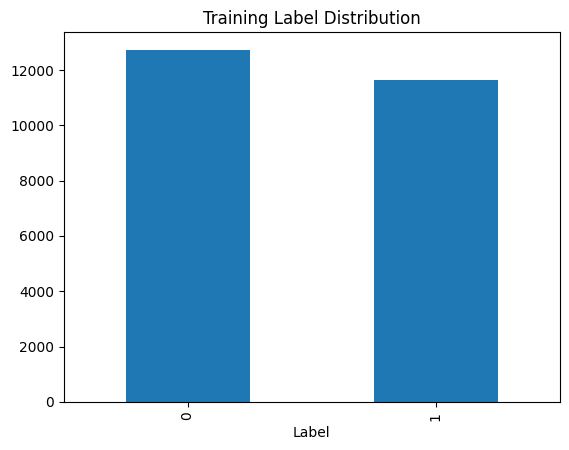

In [3]:
# Count samples in each class
label_distribution = pd.Series(y_train).value_counts()

print(label_distribution)

# Visualize class balance in the training set
label_distribution.plot(kind='bar')
plt.title('Training Label Distribution')
plt.show()

## Logistic Regression Implementation from Scratch

This section implements Logistic Regression using NumPy and Gradient Descent without relying on scikit-learn. The model learns the optimal weights by minimizing Binary Cross-Entropy Loss and is used for binary classification.

In [4]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.1, epochs=500):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    # Sigmoid activation function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Binary cross-entropy loss
    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

    # Train the model using gradient descent
    def fit(self, X, y):

        if issparse(X):
            X = X.toarray()

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            linear = np.dot(X, self.weights) + self.bias
            pred = self.sigmoid(linear)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, pred - y)
            db = (1 / n_samples) * np.sum(pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = self.compute_loss(y, pred)
            self.loss_history.append(loss)

    # Return predicted probabilities
    def predict_proba(self, X):

        if issparse(X):
            X = X.toarray()

        linear = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear)

    # Convert probabilities to class labels
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

## Train the Scratch Model

Initialize and train the custom Logistic Regression model using the training dataset. After training, predictions are generated on the test set for performance evaluation.

In [5]:
# Initialize the model with predefined hyperparameters
scratch_model = LogisticRegressionScratch(
    learning_rate=0.1,
    epochs=500
)

# Train the model on the training set
scratch_model.fit(X_train, y_train)

# Generate predictions on the test set
scratch_pred = scratch_model.predict(X_test)

## Evaluate the Scratch Model

Evaluate the performance of the custom Logistic Regression model using common classification metrics, including Accuracy, Precision, Recall, and F1-Score.

In [6]:
# Calculate classification metrics
scratch_accuracy = accuracy_score(y_test, scratch_pred)
scratch_precision = precision_score(y_test, scratch_pred)
scratch_recall = recall_score(y_test, scratch_pred)
scratch_f1 = f1_score(y_test, scratch_pred)

# Display model performance
print(f'Accuracy : {scratch_accuracy:.4f}')
print(f'Precision: {scratch_precision:.4f}')
print(f'Recall   : {scratch_recall:.4f}')
print(f'F1 Score : {scratch_f1:.4f}')

Accuracy : 0.9601
Precision: 0.9717
Recall   : 0.9441
F1 Score : 0.9577


## Training Loss Curve

Visualize the change in Binary Cross-Entropy Loss during training. A decreasing loss indicates that the model is learning and converging toward an optimal solution.

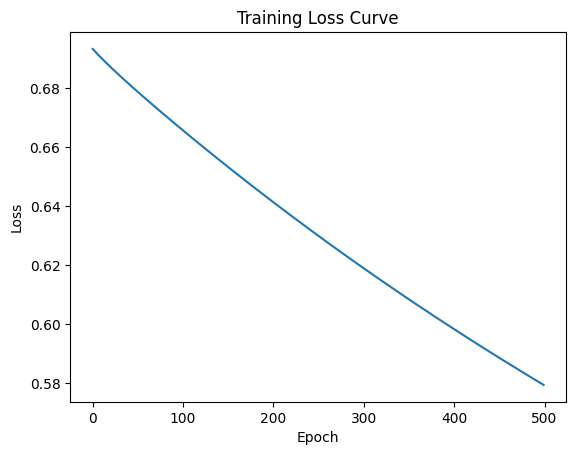

In [7]:
# Plot the loss value across training epochs
plt.plot(scratch_model.loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Train the Baseline Model

Train a Logistic Regression model using scikit-learn with default settings. This baseline model serves as a reference for comparing the performance of the custom implementation and the tuned model.

In [8]:
# Initialize the baseline Logistic Regression model
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model on the training set
baseline_model.fit(X_train, y_train)

# Generate predictions on the test set
baseline_pred = baseline_model.predict(X_test)

# Calculate classification metrics
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

## Hyperparameter Tuning

Use Grid Search with 5-fold Cross-Validation to identify the optimal combination of hyperparameters for Logistic Regression. The model is evaluated using the F1-score to achieve a balance between Precision and Recall.

In [9]:
param_grid = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs'],
    'max_iter':[1000,2000]
}

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Retrieve the best model
best_model = grid_search.best_estimator_

# Display the best hyperparameters and cross-validation score
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
0.9840509525137151


## Cross-Validation Performance

Evaluate the tuned Logistic Regression model using 5-fold Cross-Validation. The mean F1-score measures overall performance, while the standard deviation indicates the model's stability across different folds.

In [10]:
# Evaluate model stability using 5-fold cross-validation
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

# Display cross-validation results
print('Mean CV F1:', cv_scores.mean())
print('STD CV F1 :', cv_scores.std())

Mean CV F1: 0.9840509525137151
STD CV F1 : 0.0007585026921838812


## Evaluate the Tuned Model

Assess the performance of the optimized Logistic Regression model on the test dataset. Key classification metrics and a detailed classification report are used to evaluate the model's predictive capability.

In [11]:
# Generate predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display model performance
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

# Display the detailed classification report
print(classification_report(y_test, y_pred))

Accuracy : 0.9847
Precision: 0.9793
Recall   : 0.9890
F1 Score : 0.9841
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3182
           1       0.98      0.99      0.98      2914

    accuracy                           0.98      6096
   macro avg       0.98      0.98      0.98      6096
weighted avg       0.98      0.98      0.98      6096



## Confusion Matrix

Visualize the classification results using a confusion matrix. This helps identify correctly classified emails as well as false positives and false negatives.

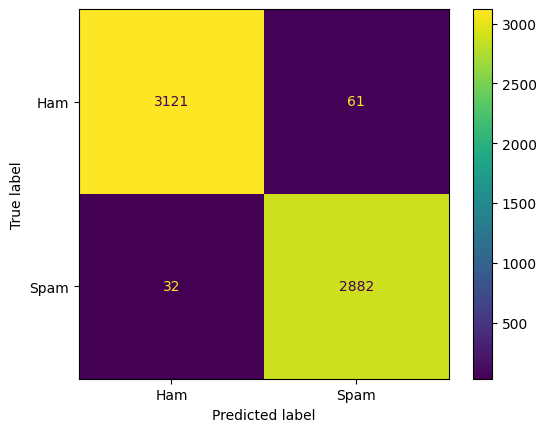

In [12]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize prediction results
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
).plot()

plt.show()

## Performance Comparison

Compare the evaluation results of the custom Logistic Regression implementation and the optimized scikit-learn model across key classification metrics.

In [13]:
# Compare the performance of both implementations
comparison = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1'],
    'Scratch':[scratch_accuracy, scratch_precision, scratch_recall, scratch_f1],
    'Scikit-Learn':[accuracy, precision, recall, f1]
})

comparison

,Metric,Scratch,Scikit-Learn
0,Accuracy,0.960138,0.984744
1,Precision,0.971741,0.979273
2,Recall,0.944063,0.989019
3,F1,0.957702,0.984122



## 10. Statistical Interpretation of Logistic Regression

Logistic Regression is a probabilistic classification algorithm. Instead of directly predicting a class label, it estimates the probability that an email belongs to the Spam class.

### Sigmoid Function

The sigmoid function transforms a linear combination of features into a probability value between 0 and 1.

### Binary Cross-Entropy Loss

The model learns by minimizing Binary Cross-Entropy Loss using Gradient Descent. During training, weights are iteratively updated to reduce prediction error.

### Why Hyperparameter Tuning and Cross-Validation?

Hyperparameter Tuning is performed to identify the best parameter combination on the training data.

Cross-Validation provides a statistically reliable estimate of model performance by evaluating the model on multiple folds rather than a single train-validation split. This reduces selection bias and helps choose a model that generalizes better to unseen data.



## 11. Hyperparameter Tuning and Overfitting / Underfitting Analysis

After Grid Search, analyze:

- Best Parameters (`best_params_`)
- Best Cross-Validation Score (`best_score_`)
- Mean Cross-Validation F1 Score
- Test F1 Score

Interpretation:

- CV F1 ≈ Test F1 → Good Generalization
- CV F1 >> Test F1 → Potential Overfitting
- CV F1 low and Test F1 low → Underfitting

A small difference between Cross-Validation and Test performance suggests that the model learned meaningful patterns rather than memorizing the training data.


In [ ]:

print('Best Parameters:', grid_search.best_params_)
print('Best CV Score  :', grid_search.best_score_)

gap = abs(cv_scores.mean() - f1)

print(f'CV F1 Score   : {cv_scores.mean():.4f}')
print(f'Test F1 Score : {f1:.4f}')
print(f'Gap           : {gap:.4f}')

if gap < 0.02:
    print('Interpretation: No significant overfitting. Good generalization ability.')
elif cv_scores.mean() > f1:
    print('Interpretation: Potential overfitting detected.')
else:
    print('Interpretation: Model may be underfitting or unstable.')


## 12. Conclusion

Logistic Regression provides an effective baseline for spam email classification. Compare Scratch and Scikit-Learn results and discuss the final performance.



## 12. Unseen Data and Deployment Discussion

Although the model performs well on the held-out test set, no machine learning model can guarantee perfect performance on future unseen emails.

Potential challenges in production:

- Data Drift: Spam patterns evolve over time.
- Distribution Shift: Real-world emails may differ from training data.
- Emerging Spam Techniques: New spam strategies may not exist in the current dataset.

To maintain performance:

- Monitor prediction quality after deployment.
- Periodically retrain the model with new email samples.
- Re-run Hyperparameter Tuning when sufficient new data becomes available.

Therefore, strong test performance increases confidence, but does not guarantee identical performance on all future unseen data.



## 13. Conclusion

Logistic Regression achieved strong performance for spam email classification.

Key findings:

- Hyperparameter Tuning identified the most effective parameter combination.
- Cross-Validation provided a statistically reliable estimate of generalization performance.
- The comparison between Cross-Validation and Test F1 scores was used to assess overfitting and underfitting risk.
- The Scikit-Learn implementation was compared against the custom implementation from scratch.
- The model demonstrates good predictive capability and can serve as a strong baseline for spam email classification.

Future improvements may include additional feature engineering, ensemble methods, and periodic retraining to address data drift in production environments.
